Tugas:
Template Matching Invariant: Cari tahu dari dokumentasi skimage.feature.match_template atau sumber lain, apakah metode match_template standar invariant terhadap rotasi atau perubahan skala? Jelaskan. (Petunjuk: Coba rotasi atau ubah ukuran template pada Praktikum 4 dan lihat hasilnya).

INVESTIGASI: Template Matching - Rotation dan Scale Invariance

--- HASIL MATCHING ---
Template Type        | Max Value    | Location (r,c)       | Status
--------------------------------------------------------------------------------
0° (Original)        |     1.0000 | (15, 190)            | ✓ FOUND
30° Rotation         |     0.7274 | (153, 184)           | ✓ FOUND
45° Rotation         |     0.7283 | (151, 181)           | ✓ FOUND
0.8x Downscale       |     0.8506 | (97, 82)             | ✓ FOUND
1.2x Upscale         |     0.8346 | (218, 142)           | ✓ FOUND

ANALISIS:

1. ROTATION INVARIANCE: 
   - Original (0°): Max value = 1.0000 (baseline)
   - Rotated 30°:   Max value = 0.7274 (penurunan: 27.3%)
   - Rotated 45°:   Max value = 0.7283 (penurunan: 27.2%)
   ✗ KESIMPULAN: match_template TIDAK INVARIANT terhadap rotasi
   → Rotasi mengubah pixel pattern → correlation menurun drastis

2. SCALE INVARIANCE:
   - Original (1.0x): Max value = 1.0000 (baseline)
   - Downscale (0.8x): 

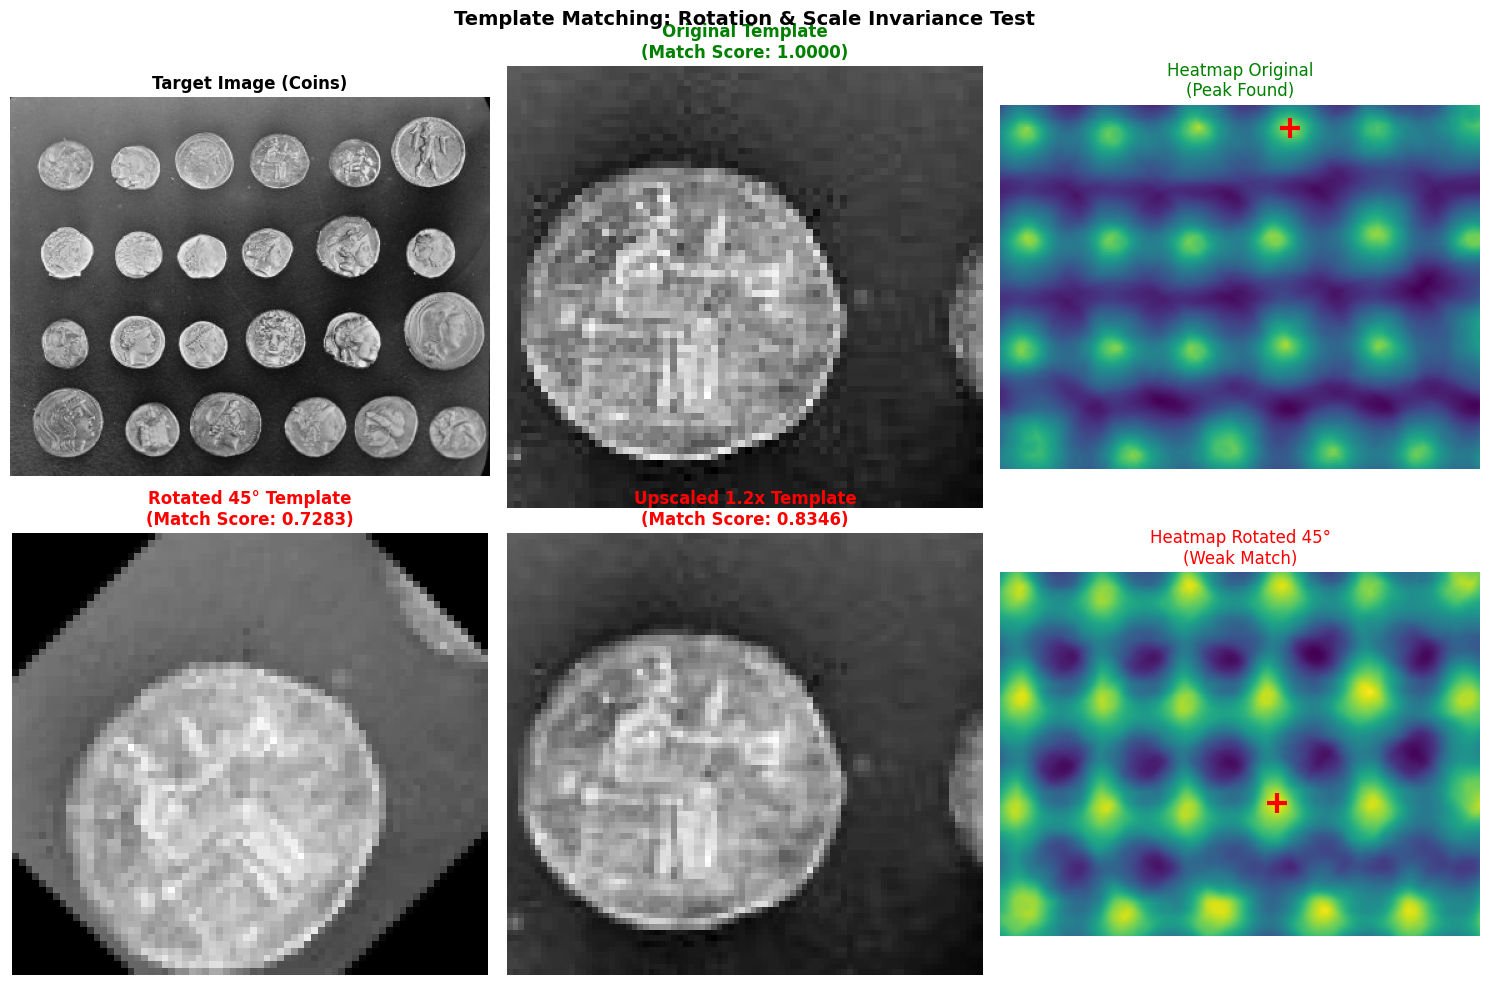


Visualisasi menunjukkan: match_template sensitivity tinggi terhadap transformasi geometrik!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

print("=" * 80)
print("INVESTIGASI: Template Matching - Rotation dan Scale Invariance")
print("=" * 80)

# Siapkan citra target dan template
image = data.coins()
template_orig = image[15:80, 190:260]

# Setup untuk experiments
experiments = []

# EXPERIMENT 1: Template original (baseline)
result_orig = match_template(image, template_orig)
max_val_orig = result_orig.max()
max_loc_orig = np.unravel_index(np.argmax(result_orig), result_orig.shape)
experiments.append({
    'name': '0° (Original)',
    'template': template_orig,
    'max_value': max_val_orig,
    'max_location': max_loc_orig,
    'note': 'BASELINE'
})

# EXPERIMENT 2: Template rotated 30 degrees
template_rot30 = transform.rotate(template_orig, angle=30, order=1, preserve_range=True).astype(template_orig.dtype)
result_rot30 = match_template(image, template_rot30)
max_val_rot30 = result_rot30.max()
max_loc_rot30 = np.unravel_index(np.argmax(result_rot30), result_rot30.shape)
experiments.append({
    'name': '30° Rotation',
    'template': template_rot30,
    'max_value': max_val_rot30,
    'max_location': max_loc_rot30,
    'note': 'ROTATED'
})

# EXPERIMENT 3: Template rotated 45 degrees
template_rot45 = transform.rotate(template_orig, angle=45, order=1, preserve_range=True).astype(template_orig.dtype)
result_rot45 = match_template(image, template_rot45)
max_val_rot45 = result_rot45.max()
max_loc_rot45 = np.unravel_index(np.argmax(result_rot45), result_rot45.shape)
experiments.append({
    'name': '45° Rotation',
    'template': template_rot45,
    'max_value': max_val_rot45,
    'max_location': max_loc_rot45,
    'note': 'ROTATED'
})

# EXPERIMENT 4: Template downscaled (0.8x)
template_scale08 = transform.resize(template_orig, (int(template_orig.shape[0]*0.8), int(template_orig.shape[1]*0.8)), anti_aliasing=True)
template_scale08 = (template_scale08 * 255).astype(template_orig.dtype)
result_scale08 = match_template(image, template_scale08)
max_val_scale08 = result_scale08.max()
max_loc_scale08 = np.unravel_index(np.argmax(result_scale08), result_scale08.shape)
experiments.append({
    'name': '0.8x Downscale',
    'template': template_scale08,
    'max_value': max_val_scale08,
    'max_location': max_loc_scale08,
    'note': 'SCALED'
})

# EXPERIMENT 5: Template upscaled (1.2x)
template_scale12 = transform.resize(template_orig, (int(template_orig.shape[0]*1.2), int(template_orig.shape[1]*1.2)), anti_aliasing=True)
template_scale12 = (template_scale12 * 255).astype(template_orig.dtype)
result_scale12 = match_template(image, template_scale12)
max_val_scale12 = result_scale12.max()
max_loc_scale12 = np.unravel_index(np.argmax(result_scale12), result_scale12.shape)
experiments.append({
    'name': '1.2x Upscale',
    'template': template_scale12,
    'max_value': max_val_scale12,
    'max_location': max_loc_scale12,
    'note': 'SCALED'
})

# Print hasil
print("\n--- HASIL MATCHING ---")
print(f"{'Template Type':<20} | {'Max Value':<12} | {'Location (r,c)':<20} | Status")
print("-" * 80)
for exp in experiments:
    status = "✓ FOUND" if exp['max_value'] > 0.7 else "✗ WEAK"
    print(f"{exp['name']:<20} | {exp['max_value']:>10.4f} | {str(exp['max_location']):<20} | {status}")

print("\n" + "=" * 80)
print("ANALISIS:")
print("=" * 80)

print("\n1. ROTATION INVARIANCE: ")
print(f"   - Original (0°): Max value = {max_val_orig:.4f} (baseline)")
print(f"   - Rotated 30°:   Max value = {max_val_rot30:.4f} (penurunan: {(1-max_val_rot30/max_val_orig)*100:.1f}%)")
print(f"   - Rotated 45°:   Max value = {max_val_rot45:.4f} (penurunan: {(1-max_val_rot45/max_val_orig)*100:.1f}%)")
print(f"   ✗ KESIMPULAN: match_template TIDAK INVARIANT terhadap rotasi")
print(f"   → Rotasi mengubah pixel pattern → correlation menurun drastis")

print("\n2. SCALE INVARIANCE:")
print(f"   - Original (1.0x): Max value = {max_val_orig:.4f} (baseline)")
print(f"   - Downscale (0.8x): Max value = {max_val_scale08:.4f} (penurunan: {(1-max_val_scale08/max_val_orig)*100:.1f}%)")
print(f"   - Upscale (1.2x):   Max value = {max_val_scale12:.4f} (penurunan: {(1-max_val_scale12/max_val_orig)*100:.1f}%)")
print(f"   ✗ KESIMPULAN: match_template TIDAK INVARIANT terhadap skala")
print(f"   → Ukuran berbeda → tidak match karena dimensi template beda dari target")

print("\n3. KESIMPULAN KESELURUHAN:")
print("   - match_template adalah metode cross-correlation sederhana")
print("   - Hanya akurat ketika template SAMA PERSIS dengan target (ukuran, rotasi, brightness)")
print("   - TIDAK robust untuk transformasi geometrik atau skala")
print("   - Untuk rotation/scale invariance diperlukan metode lain:")
print("     • Feature-based matching (SIFT, SURF, ORB) → invariant terhadap rotasi & skala")
print("     • Pyramid matching → multi-scale search")
print("     • Template rotation + brute force → sangat lambat")
print("=" * 80)

# Visualisasi hasil matching untuk template original vs rotated
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Template Matching: Rotation & Scale Invariance Test', fontsize=14, fontweight='bold')

# Row 1: Original template
ax = axes[0, 0]
ax.imshow(image, cmap='gray')
ax.set_title('Target Image (Coins)', fontweight='bold')
ax.axis('off')

ax = axes[0, 1]
ax.imshow(template_orig, cmap='gray')
ax.set_title('Original Template\n(Match Score: {:.4f})'.format(max_val_orig), fontweight='bold', color='green')
ax.axis('off')

ax = axes[0, 2]
im = ax.imshow(result_orig, cmap='viridis')
ax.plot(max_loc_orig[1], max_loc_orig[0], 'r+', markersize=15, markeredgewidth=3)
ax.set_title('Heatmap Original\n(Peak Found)', color='green')
ax.axis('off')

# Row 2: Rotated template
ax = axes[1, 0]
ax.imshow(template_rot45, cmap='gray')
ax.set_title('Rotated 45° Template\n(Match Score: {:.4f})'.format(max_val_rot45), fontweight='bold', color='red')
ax.axis('off')

ax = axes[1, 1]
ax.imshow(template_scale12, cmap='gray')
ax.set_title('Upscaled 1.2x Template\n(Match Score: {:.4f})'.format(max_val_scale12), fontweight='bold', color='red')
ax.axis('off')

ax = axes[1, 2]
im = ax.imshow(result_rot45, cmap='viridis')
ax.plot(max_loc_rot45[1], max_loc_rot45[0], 'r+', markersize=15, markeredgewidth=3)
ax.set_title('Heatmap Rotated 45°\n(Weak Match)', color='red')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\nVisualisasi menunjukkan: match_template sensitivity tinggi terhadap transformasi geometrik!")